In [1]:
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns 

In [2]:
df= pd.read_csv("titanic.csv")
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [3]:
df.shape

(891, 12)

In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
df.describe(include="object")

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,B96 B98,S
freq,1,577,7,4,644


In [6]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [9]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [10]:
df.nunique()

PassengerId    891
Survived         2
Pclass           3
Name           891
Sex              2
Age             88
SibSp            7
Parch            7
Ticket         681
Fare           248
Cabin          147
Embarked         3
dtype: int64

array([[<Axes: title={'center': 'Age'}>]], dtype=object)

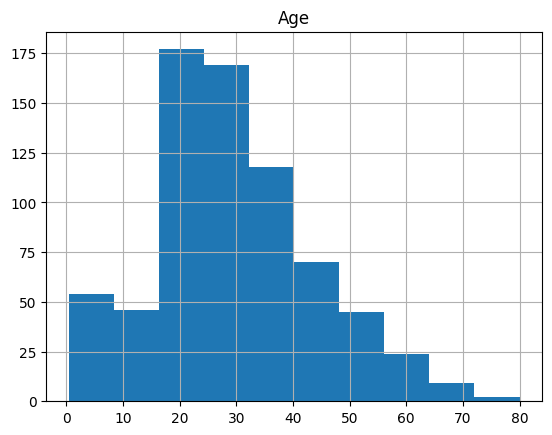

In [12]:
df.hist("Age")

In [13]:
missing = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing %": (df.isnull().sum() / len(df) * 100).round(2)
})
missing = missing[missing["Missing Count"] > 0].sort_values("Missing %", ascending=False)
print("Columns with missing values:")
missing

Columns with missing values:


,Missing Count,Missing %
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22


In [14]:
df["Has_Cabin"] = df["Cabin"].notna().astype(int)

print("Survival Rate with having a Cabin: ")
print(df.groupby("Has_Cabin")["Survived"].mean())
print("\nPassengers with a cabin number had a much higher survival rate!")
print("We'll keep HasCabin as a feature and drop the raw Cabin column.")

Survival Rate with having a Cabin: 
Has_Cabin
0    0.299854
1    0.666667
Name: Survived, dtype: float64

Passengers with a cabin number had a much higher survival rate!
We'll keep HasCabin as a feature and drop the raw Cabin column.


In [15]:
df = df.drop(columns = "Cabin")

In [18]:
df["Has_Cabin"]

0      0
1      1
2      0
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: Has_Cabin, Length: 891, dtype: int64

In [30]:
# AGE

In [19]:
df["Name"]

0                                Braund, Mr. Owen Harris
1      Cumings, Mrs. John Bradley (Florence Briggs Th...
2                                 Heikkinen, Miss. Laina
3           Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                               Allen, Mr. William Henry
                             ...                        
886                                Montvila, Rev. Juozas
887                         Graham, Miss. Margaret Edith
888             Johnston, Miss. Catherine Helen "Carrie"
889                                Behr, Mr. Karl Howell
890                                  Dooley, Mr. Patrick
Name: Name, Length: 891, dtype: object

In [20]:
#Pandas nimmt den Namen, teilt ihn am Komma, nimmt den rechten Teil, teilt diesen am Punkt, nimmt den linken Teil davon und putzt die Leerzeichen weg.

df["Title"] = df["Name"].str.split(",").str[1].str.split(".").str[0].str.strip()

In [21]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Has_Cabin,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,0,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,1,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,0,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,1,Mrs
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,0,Mr
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S,0,Rev
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S,1,Miss
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,S,0,Miss
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C,1,Mr


In [22]:
df["Title"].value_counts()

Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Mlle              2
Major             2
Col               2
the Countess      1
Capt              1
Ms                1
Sir               1
Lady              1
Mme               1
Don               1
Jonkheer          1
Name: count, dtype: int64

In [23]:
# Wir legen Title zusammen. Es gibt zu viele Ausreißer die keine große Bedeutung haben
ersetzung = {
    "Mlle": "Miss",
    "Ms": "Miss",
    "Mme": "Mrs",
    "Dr": "Rare",
    "Rev": "Rare",
    "Major": "Rare",
    "Col": "Rare",
    "the Countess": "Rare",
    "Capt": "Rare",
    "Sir": "Rare",
    "Lady": "Rare",
    "Don": "Rare",
    "Jonkheer": "Rare"
}



df["Title"] = df["Title"].replace(ersetzung)


In [24]:
df["Title"].value_counts()

Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64

In [25]:
df.groupby("Title")["Age"].median()

Title
Master     3.5
Miss      21.0
Mr        30.0
Mrs       35.0
Rare      48.5
Name: Age, dtype: float64

In [27]:
#Trägt das median Alter automatisch in die fehlende Spalte ein
df["Age"] = df["Age"].fillna(df.groupby("Title")["Age"].transform("median"))

In [28]:
häufigster_hafen = df["Embarked"].mode()[0]
df["Embarked"] = df["Embarked"].fillna(häufigster_hafen)

In [30]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
Has_Cabin      0
Title          0
dtype: int64

In [35]:
df.groupby("Sex")["Survived"].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [36]:
df.groupby("Pclass")["Age"].median()

Pclass
1    35.0
2    30.0
3    27.0
Name: Age, dtype: float64

In [40]:
df.groupby("Has_Cabin")["Survived"].mean()

Has_Cabin
0    0.299854
1    0.666667
Name: Survived, dtype: float64

In [57]:
print(df.groupby(["Pclass", "Has_Cabin"])["Survived"].mean())
print("Wer eine Kabine hatte, derjenige hatte so größere Überlebenschance")

Pclass  Has_Cabin
1       0            0.475000
        1            0.664773
2       0            0.440476
        1            0.812500
3       0            0.235908
        1            0.500000
Name: Survived, dtype: float64
Wer eine Kabine hatte, derjenige hatte so größere Überlebenschance


In [56]:
print(df.groupby(["Sex" , "Pclass"])["Survived"].mean())

print("Frauen in der 1&2 Klasse hatten eine große Warscheinlichkeit zu überleben! Männer hingegen nicht mal eine 50% Chance!")

Sex     Pclass
female  1         0.968085
        2         0.921053
        3         0.500000
male    1         0.368852
        2         0.157407
        3         0.135447
Name: Survived, dtype: float64
Frauen in der 1&2 Klasse hatten eine große Warscheinlichkeit zu überleben! Männer hingegen nicht mal eine 50% Chance!


In [47]:
# Familiengröße analysieren. Wer hatte eine größere Warscheinlichkeit zu überleben? 
# Kleine oder große Familien ? 
df["Family_Size"] = df["SibSp"] + df["Parch"] + 1 

In [48]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Has_Cabin,Title,Family_Size
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,0,Mr,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,1,Mrs,2
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,0,Miss,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,1,Mrs,2
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,0,Mr,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S,0,Rare,1
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S,1,Miss,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,21.0,1,2,W./C. 6607,23.4500,S,0,Miss,4
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C,1,Mr,1


In [55]:
print(df.groupby("Family_Size")["Survived"].mean())
print("\nFamilien zwischen 2-4 Personen hatten eine große Warscheinlichkeit zu überleben, als Singles oder Großfamilien")

Family_Size
1     0.303538
2     0.552795
3     0.578431
4     0.724138
5     0.200000
6     0.136364
7     0.333333
8     0.000000
11    0.000000
Name: Survived, dtype: float64

Familien zwischen 2-4 Personen hatten eine große Warscheinlichkeit zu überleben, als Singles oder Großfamilien


In [60]:
df ["Sex"] = df["Sex"].replace({
    "male" : 1, 
    "female" : 0} )

/var/folders/w3/dr79nrrd49s6kd7trrw92kbh0000gn/T/ipykernel_4503/308067122.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df ["Sex"] = df["Sex"].replace({


In [61]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Has_Cabin,Title,Family_Size
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,S,0,Mr,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C,1,Mrs,2
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,S,0,Miss,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,S,1,Mrs,2
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,S,0,Mr,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",1,27.0,0,0,211536,13.0000,S,0,Rare,1
887,888,1,1,"Graham, Miss. Margaret Edith",0,19.0,0,0,112053,30.0000,S,1,Miss,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",0,21.0,1,2,W./C. 6607,23.4500,S,0,Miss,4
889,890,1,1,"Behr, Mr. Karl Howell",1,26.0,0,0,111369,30.0000,C,1,Mr,1


In [69]:
df = pd.get_dummies(df, columns = ["Title", "Embarked"])

KeyError: "None of [Index(['Title', 'Embarked'], dtype='object')] are in the [columns]"

In [71]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Has_Cabin,Family_Size,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_Rare,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,0,2,False,False,True,False,False,False,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,1,2,False,False,False,True,False,True,False,False
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,0,1,False,True,False,False,False,False,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,1,2,False,False,False,True,False,False,False,True
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,0,1,False,False,True,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",1,27.0,0,0,211536,13.0000,0,1,False,False,False,False,True,False,False,True
887,888,1,1,"Graham, Miss. Margaret Edith",0,19.0,0,0,112053,30.0000,1,1,False,True,False,False,False,False,False,True
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",0,21.0,1,2,W./C. 6607,23.4500,0,4,False,True,False,False,False,False,False,True
889,890,1,1,"Behr, Mr. Karl Howell",1,26.0,0,0,111369,30.0000,1,1,False,False,True,False,False,True,False,False


In [72]:
df.isnull().sum()

PassengerId     0
Survived        0
Pclass          0
Name            0
Sex             0
Age             0
SibSp           0
Parch           0
Ticket          0
Fare            0
Has_Cabin       0
Family_Size     0
Title_Master    0
Title_Miss      0
Title_Mr        0
Title_Mrs       0
Title_Rare      0
Embarked_C      0
Embarked_Q      0
Embarked_S      0
dtype: int64

In [73]:
df= df.drop(["Name" , "Ticket", "PassengerId"], axis=1)

In [74]:
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Has_Cabin,Family_Size,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_Rare,Embarked_C,Embarked_Q,Embarked_S
0,0,3,1,22.0,1,0,7.2500,0,2,False,False,True,False,False,False,False,True
1,1,1,0,38.0,1,0,71.2833,1,2,False,False,False,True,False,True,False,False
2,1,3,0,26.0,0,0,7.9250,0,1,False,True,False,False,False,False,False,True
3,1,1,0,35.0,1,0,53.1000,1,2,False,False,False,True,False,False,False,True
4,0,3,1,35.0,0,0,8.0500,0,1,False,False,True,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,1,27.0,0,0,13.0000,0,1,False,False,False,False,True,False,False,True
887,1,1,0,19.0,0,0,30.0000,1,1,False,True,False,False,False,False,False,True
888,0,3,0,21.0,1,2,23.4500,0,4,False,True,False,False,False,False,False,True
889,1,1,1,26.0,0,0,30.0000,1,1,False,False,True,False,False,True,False,False


In [75]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 17 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Survived      891 non-null    int64  
 1   Pclass        891 non-null    int64  
 2   Sex           891 non-null    int64  
 3   Age           891 non-null    float64
 4   SibSp         891 non-null    int64  
 5   Parch         891 non-null    int64  
 6   Fare          891 non-null    float64
 7   Has_Cabin     891 non-null    int64  
 8   Family_Size   891 non-null    int64  
 9   Title_Master  891 non-null    bool   
 10  Title_Miss    891 non-null    bool   
 11  Title_Mr      891 non-null    bool   
 12  Title_Mrs     891 non-null    bool   
 13  Title_Rare    891 non-null    bool   
 14  Embarked_C    891 non-null    bool   
 15  Embarked_Q    891 non-null    bool   
 16  Embarked_S    891 non-null    bool   
dtypes: bool(8), float64(2), int64(7)
memory usage: 69.7 KB


In [76]:
# Jetzt beginnen wir das Modell zu trainieren

In [91]:
y = df["Survived"]

In [92]:
X = df.drop(["Survived"], axis= 1)

In [93]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state = 42)

In [94]:
from sklearn.tree import DecisionTreeClassifier
model  = DecisionTreeClassifier()

model.fit(X_train, y_train)

model.score(X_test, y_test)

In [96]:
model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [97]:
model.score(X_test, y_test)

0.7821229050279329